In [3]:
import staircase_to_stimuli as ss
import os

# plot mocs curves for each subject separately

repo_dir = os.getcwd()
data_dir = os.path.join(repo_dir, 'tilt_mocs','data')
#loop thru subjects (only the directories that start with sub there are no letters after sub just numbers, so not sub-eliza but yes sub-21040096)
all_subs = [d for d in os.listdir(data_dir) if d.startswith('sub-') and d[4:].isdigit()]
#get the subs whose IDs are greater than or equal to 21049995
stair_subs = [d for d in all_subs if int(d[4:]) >= 21049995]
#get the subs whose IDs are less than 21049995
fixed_subs = [d for d in all_subs if int(d[4:]) < 21049995]

In [ ]:
#plot stair subs
for sub in stair_subs:
    print(f'Plotting MOCS for subject {sub}...')
    sub_data_dir = os.path.join(data_dir, sub,'ses-0')
    csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')] #find the csv filename (it's the only csv in the folder)
    mocs_csv = os.path.join(sub_data_dir, csv_files[0])
    ss.plot_mocs_from_csv(mocs_csv)

ValueError: Fixed MoCS file missing required column: center

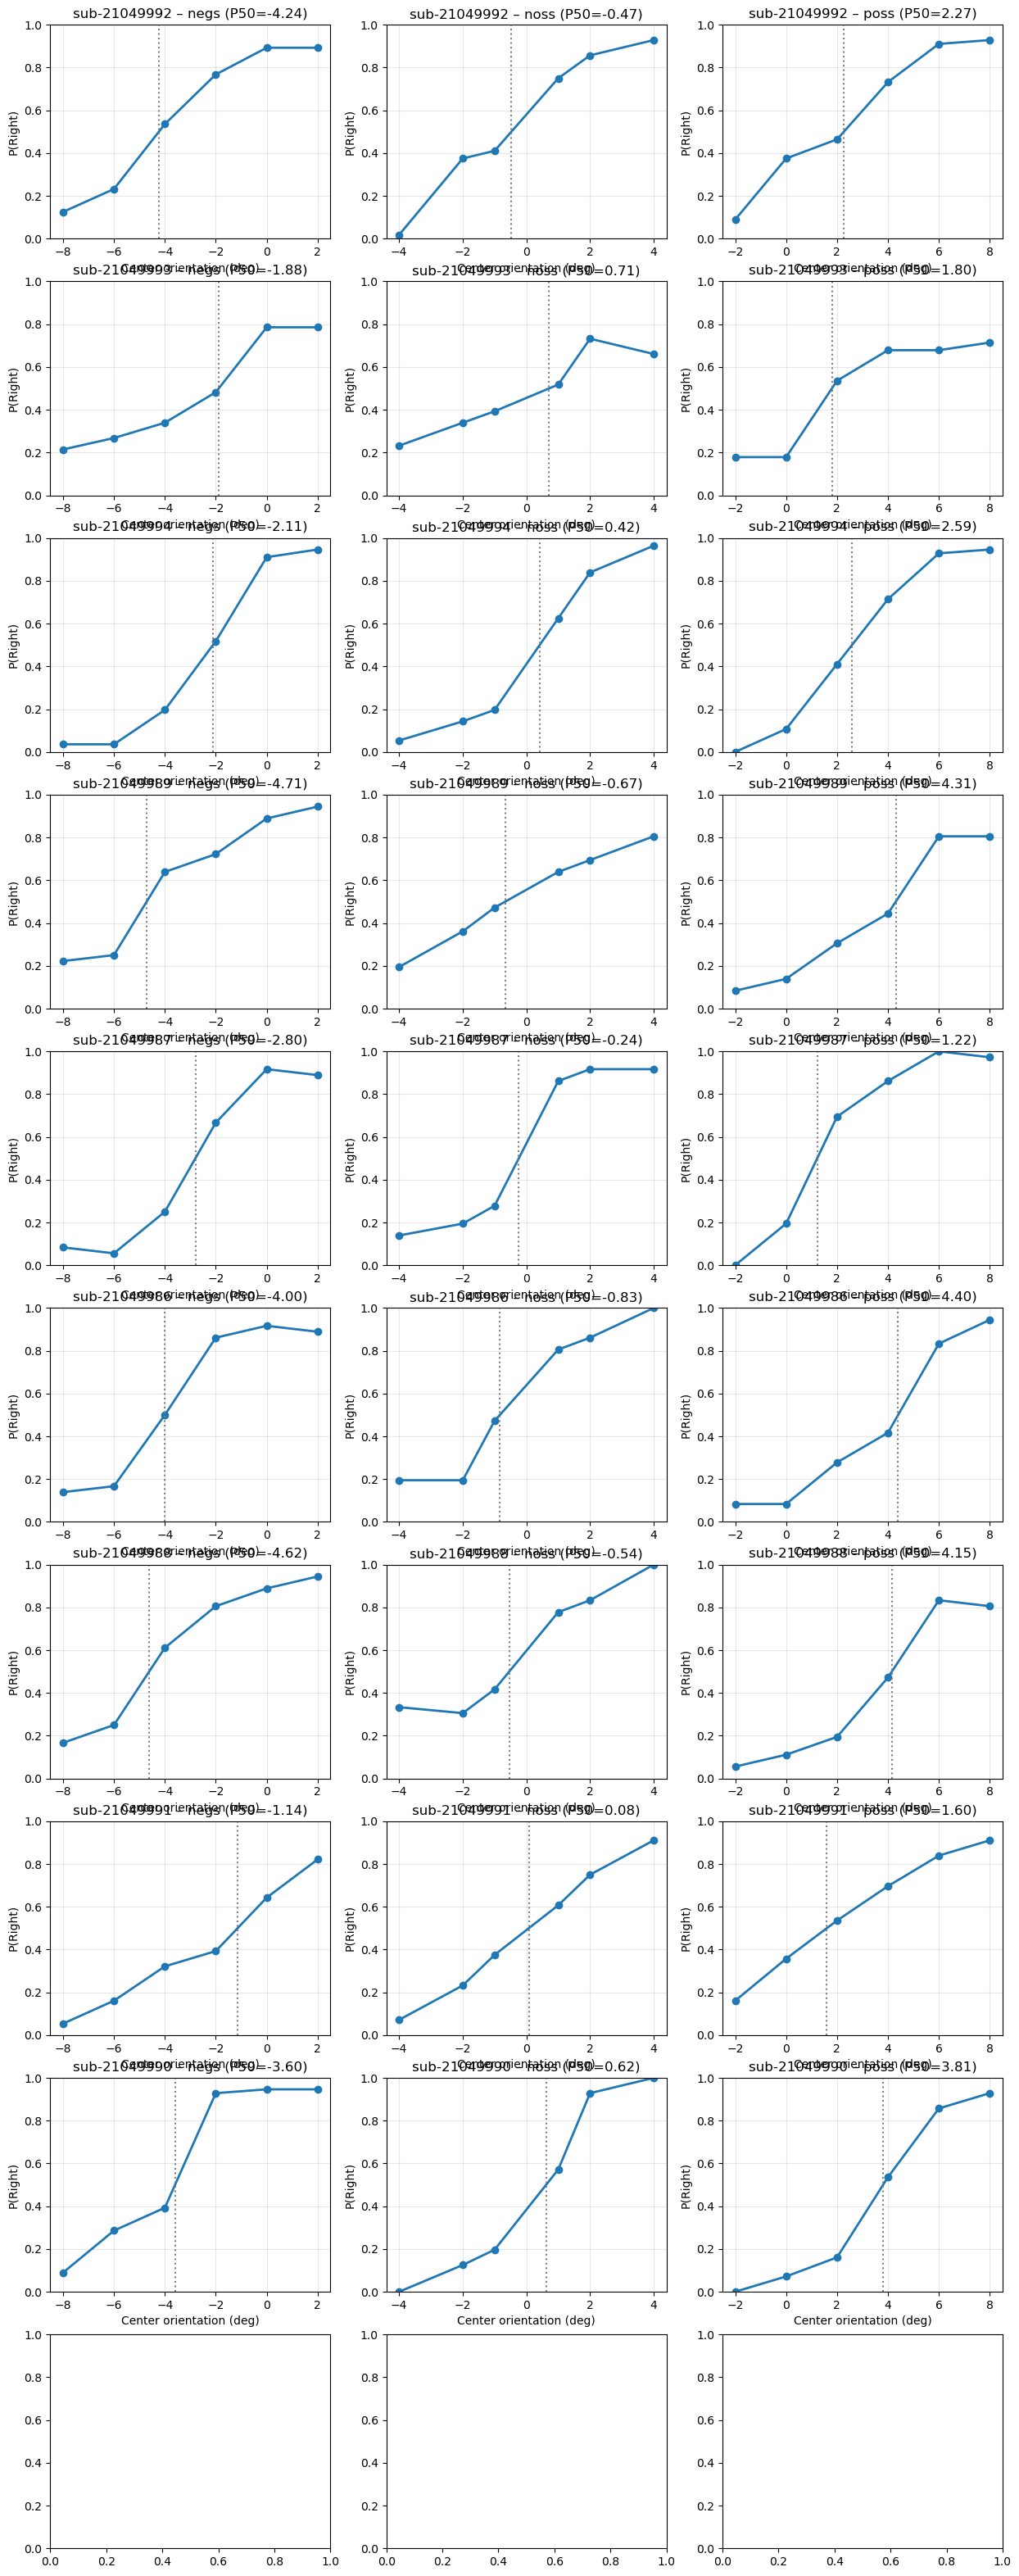

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import importlib
importlib.reload(ss)  # Reload to pick up any changes to staircase_to_stimuli

def find_p50_crossing(x, y):
    """Find x-value where curve crosses P=0.5 using linear interpolation."""
    for i in range(len(y) - 1):
        if (y[i] <= 0.5 <= y[i+1]) or (y[i] >= 0.5 >= y[i+1]):
            if y[i+1] - y[i] != 0:
                return x[i] + (0.5 - y[i]) * (x[i+1] - x[i]) / (y[i+1] - y[i])
    return None

# Collect all subject data
subject_data = {}
for sub in fixed_subs:
    sub_data_dir = os.path.join(data_dir, sub, 'ses-0')
    csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')]
    if csv_files:
        mocs_csv = os.path.join(sub_data_dir, csv_files[0])
        df = pd.read_csv(mocs_csv)
        # Normalize response keys: z -> left, period -> right
        if 'resp.keys' in df.columns:
            df['resp.keys'] = df['resp.keys'].replace({'z': 'left', 'period': 'right'})
        subject_data[sub] = df

# Create mega figure: rows=subjects, columns=[negs, noss, poss]
n_subs = len(subject_data)
fig, axes = plt.subplots(n_subs, 3, figsize=(15, 4*n_subs))

surr_order = ['negs', 'noss', 'poss']  # Left to right column order

for row, (sub, df) in enumerate(subject_data.items()):
    tables = ss.fixed_mocs_psychometric_tables(df)
    
    for col, surr_type in enumerate(surr_order):
        ax = axes[row, col] if n_subs > 1 else axes[col]
        
        if surr_type in tables:
            tab = tables[surr_type]
            x = tab["center"].to_numpy()
            y = tab["p_right"].to_numpy()
            order = np.argsort(x)
            x, y = x[order], y[order]
            
            ax.plot(x, y, "o-", linewidth=2, markersize=6)
            ax.set_ylim(0, 1)
            
            # Vertical line at P(50) crossing
            p50_x = find_p50_crossing(x, y)
            if p50_x is not None:
                ax.axvline(p50_x, linestyle=":", color='gray')
                ax.set_title(f"{sub} – {surr_type} (P50={p50_x:.2f})")
            else:
                ax.set_title(f"{sub} – {surr_type}")
            
            ax.set_xlabel("Center orientation (deg)")
            ax.set_ylabel("P(Right)")
            ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('/Users/bwinsto2/Downloads/fixed_mocs_mega_figure.png', dpi=300)
plt.show()

# ============== OVERLAY FIGURE ==============
# Plot all subjects overlaid with 60% opacity, plus average in black

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

# Store data for averaging
all_curves = {surr: [] for surr in surr_order}
common_x = np.linspace(-10, 10, 100)  # Common x-grid for interpolation

for sub, df in subject_data.items():
    tables = ss.fixed_mocs_psychometric_tables(df)
    
    for col, surr_type in enumerate(surr_order):
        ax = axes2[col]
        
        if surr_type in tables:
            tab = tables[surr_type]
            x = tab["center"].to_numpy()
            y = tab["p_right"].to_numpy()
            order = np.argsort(x)
            x, y = x[order], y[order]
            
            # Plot individual subject with 60% opacity
            ax.plot(x, y, "o-", alpha=0.35, linewidth=1.5, markersize=4)
            
            # Interpolate for averaging
            if len(x) >= 2:
                y_interp = np.interp(common_x, x, y, left=np.nan, right=np.nan)
                all_curves[surr_type].append(y_interp)

# Plot averages
for col, surr_type in enumerate(surr_order):
    ax = axes2[col]
    
    if all_curves[surr_type]:
        curves_array = np.array(all_curves[surr_type])
        avg_curve = np.nanmean(curves_array, axis=0)
        
        # Plot average in black, opaque
        ax.plot(common_x, avg_curve, 'k-', linewidth=3, label='Average')
        
        # Vertical line at average P(50) crossing
        valid_mask = ~np.isnan(avg_curve)
        if np.sum(valid_mask) >= 2:
            valid_x = common_x[valid_mask]
            valid_y = avg_curve[valid_mask]
            p50_x = find_p50_crossing(valid_x, valid_y)
            if p50_x is not None:
                ax.axvline(p50_x, linestyle=":", color='black', linewidth=2)
                ax.set_title(f"{surr_type} (Avg P50={p50_x:.2f})")
            else:
                ax.set_title(surr_type)
        else:
            ax.set_title(surr_type)
    
    ax.set_ylim(0, 1)
    ax.set_xlabel("Center orientation (deg)")
    ax.set_ylabel("P(Right)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
fig2.savefig('/Users/bwinsto2/Downloads/fixed_mocs_overlay_figure.png', dpi=300)
plt.show()